## Basics

In [1]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import NLProcessing
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import itertools
from datetime import datetime


date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:01<00:00,  8.36it/s]


Numba compilation complete!
0.23.9


In [2]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20260617"

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Climbing = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\Compilation with delta\\2025deltagcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarclimbing\\images\\"

In [3]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = ["fonts"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [4]:
import textwrap


In [5]:
def osar_clustermap(data, meta, palettes, responder, figsize=(5, 10), sidebars=('NT', 'Lobes'), cluster='row', savepath=''):
    row, col = cluster == 'row', cluster == 'col'
    g = sns.clustermap(data, cmap=colormap, method='complete' if row else 'weighted', metric='euclidean',
                       yticklabels=False, xticklabels=[c.replace("_Hg_OSAR", "") for c in data.columns],
                       vmin=-1.5, vmax=1.5, row_cluster=row, col_cluster=col, annot=False,
                       row_colors=['#FFFFFF'] * len(data),
                       dendrogram_ratio=(dendrogram_size, dendrogram_size),
                       cbar_kws=dict(orientation='horizontal', ticks=[-1.5, 0, 1.5]),
                       figsize=figsize, cbar_pos=(0.92, 0.955, 0.15, 0.010))
    g.ax_cbar.tick_params(labelsize=8)

    order = g.dendrogram_row.reordered_ind if row else list(range(len(data)))
    rc, hm = g.ax_row_colors.get_position(), g.ax_heatmap.get_position()
    width = 0.03 * len(sidebars)
    g.ax_row_colors.set_position([rc.x0 + gap, rc.y0, width, rc.height])
    g.ax_heatmap.set_position([hm.x0 + gap + width - 0.02, hm.y0, hm.width - width - 0.02, hm.height])

    ax = g.ax_row_colors
    ax.clear()
    ax.set_xlim(0, len(sidebars))
    ax.set_ylim(0, len(order))
    ax.invert_yaxis()
    ax.axis('off')
    for i, idx in enumerate(order):
        for s, key in enumerate(sidebars):
            vals = meta[key + '_parsed'].iloc[idx]
            n = len(vals) if vals else 1
            for j, v in enumerate(vals):
                ax.add_patch(plt.Rectangle((s + j / n, i), 1 / n, 1,
                                           facecolor=palettes[key].get(v, '#FFFFFF'),
                                           edgecolor='white', linewidth=0.5))

    g.ax_heatmap.set_ylabel('')
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(),
                                 rotation=45 if col else 0, ha='right' if col else 'center', fontsize=9)
    NLProcessing.wrap_labels(g.ax_heatmap, 10)
    for i, idx in enumerate(order):
        g.ax_heatmap.text(1.005, i + 0.5, meta['Name_short'].iloc[idx], ha='left', va='center',
                          fontsize=9, transform=g.ax_heatmap.get_yaxis_transform())

    y = 0.97
    for key in sidebars:
        handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c, label=l)
                   for l, c in palettes[key].items() if l != 'Unknown']
        g.fig.add_artist(g.fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.33, y),
                                      ncol=len(handles), fontsize=8, frameon=False))
        y -= 0.02

    g.fig.suptitle(responder + "_OSAR", fontsize=16, x=0.55, y=0.99, fontweight='bold')
    mpl.rcParams['svg.fonttype'] = 'none'
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()
    return g


## Formulas to run


In [6]:
climbingexcel = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Climbing_" + filedate + ".xlsx")
MBONList = list(climbingexcel['MBON'].unique())

lobelocation = NLProcessing.generate_lobelocation(MBONList, "MBONlist.csv")

## OSAR Clustering

In [8]:
responder = "ACR"
data_mode = "OSAR"  # Options: "OSAR", "Climbing", "OSAR + Climbing"

totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\OSAR_bothresponders_Full_20260423.xlsx")
MBONList = list(totalmetriccomparison['MBON'].unique())
lobelocation = NLProcessing.generate_lobelocation(MBONList, "MBONlist.csv")

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
    colormap = 'coolwarm'
elif responder == 'ACR':
    responderrename = "GtACR1"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
    colormap = 'coolwarm'

df_cluster = df_cluster[~df_cluster['MBON'].isin(['R76B09', 'VT999036'])]
# Add lobe and name info
for n in df_cluster['MBON']:
    df_cluster.loc[df_cluster['MBON'] == n, 'Lobe'] = lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0]
    df_cluster.loc[df_cluster['MBON'] == n, 'Name'] = lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0]
    df_cluster.loc[df_cluster['MBON'] == n, 'NT'] = lobelocation[lobelocation['MBON'] == n]['Neurotransmitter'].values[0]

df_cluster_data = df_cluster.drop(columns=['responder', 'Lobe', 'NT', 'Name', 'MBON']).copy()
df_cluster_data.index = df_cluster['MBON']

# Filter based on data_mode
if data_mode == "OSAR":
    df_cluster_data = df_cluster_data.filter(regex='_OSAR$')
    mode_label = "OSAR only"
elif data_mode == "Climbing":
    df_cluster_data = df_cluster_data.filter(regex='_Climbing$')
    mode_label = "Climbing only"
else:
    mode_label = "OSAR + Climbing"



df_cluster['Name_short'] = df_cluster['Name']
df_cluster['Lobes_parsed'] = df_cluster['Lobe'].apply(NLProcessing.parse_lobes)
df_cluster['NT_parsed'] = df_cluster['NT'].apply(NLProcessing.parse_nt)

# Palettes
lobe_palette = {'α': '#E69F00', "α'": '#F0E442', 'β': '#009E73', "β'": '#CC79A7', 'γ': '#999999', 'Calyx': '#000000', 'Unknown': '#FFFFFF'}

# Settings
fig_width, fig_height = 5, 10
dendrogram_size = 0.08
gap = 0.008

nt_palette = {
    'Acetylcholine': '#0072B2',
    'Glutamate': "#FFCD27",
    'GABA': '#009E73',
}
palettes = {'NT': nt_palette, 'Lobes': lobe_palette}


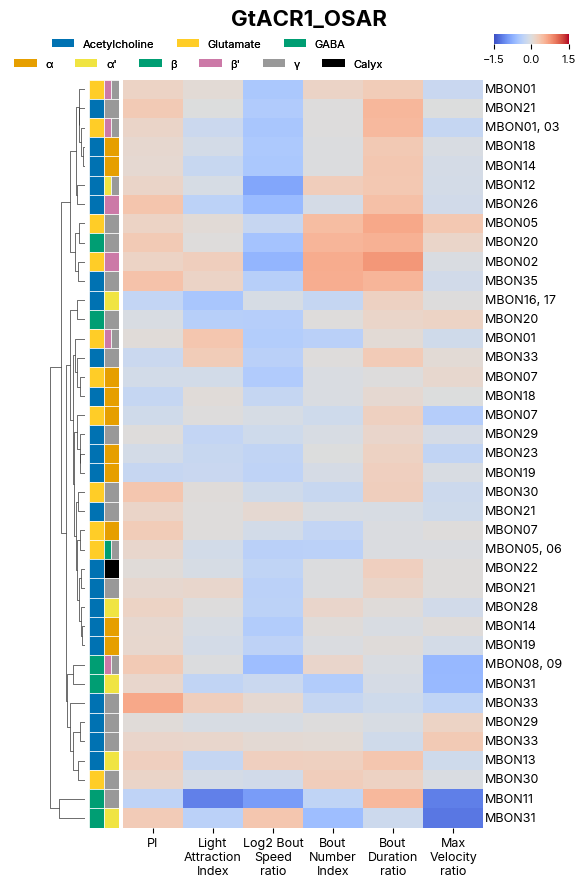

In [9]:
METRICS = ['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR', 'Log2 Bout Speed ratio_Hg_OSAR',
           'Bout Number Index_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR', 'Max Velocity ratio_Hg_OSAR']

osar_clustermap(df_cluster_data[METRICS], df_cluster, palettes, responderrename,
                figsize=(5, 10), sidebars=('NT', 'Lobes'), cluster='row')


In [ ]:
osar_clustermap(df_cluster_data[METRICS], df_cluster, palettes, responderrename,
                figsize=(5, 10), sidebars=('Lobes',), cluster='row')


In [ ]:
osar_clustermap(df_cluster_data, df_cluster, palettes, responderrename,
                figsize=(5, 10), sidebars=('Lobes',), cluster='col')


## Heatmap comparing all PIs of OSAR conditions

In [6]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

responder = "Chrimson2"

plt.rcParams["font.family"] = "Inter"

# Define the three condition files
conditions = ['Eighth','Quarter','Half', 'Full']

lightintensitycheck = pd.DataFrame()

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\OSAR and Climbing_delta Log2SR and delta Log2BSR comparison-" + condition + ".xlsx")
    
    # Extract only MBON, genotypeandresponder, and Δ PI_OSAR columns
    temp_df = totalmetriccomparison[['MBON', 'genotypeandresponder', 'Δ PI_OSAR', 'Responder']].copy()
    
    # Rename the Δ PI_OSAR column to include the condition name
    temp_df = temp_df.rename(columns={'Δ PI_OSAR': f'Δ PI_OSAR-{condition}'})
    
    # Merge with the main dataframe
    if lightintensitycheck.empty:
        lightintensitycheck = temp_df
    else:
        lightintensitycheck = lightintensitycheck.merge(temp_df, on=['MBON', 'genotypeandresponder', 'Responder'], how='outer')


<Axes: ylabel='genotypeandresponder'>

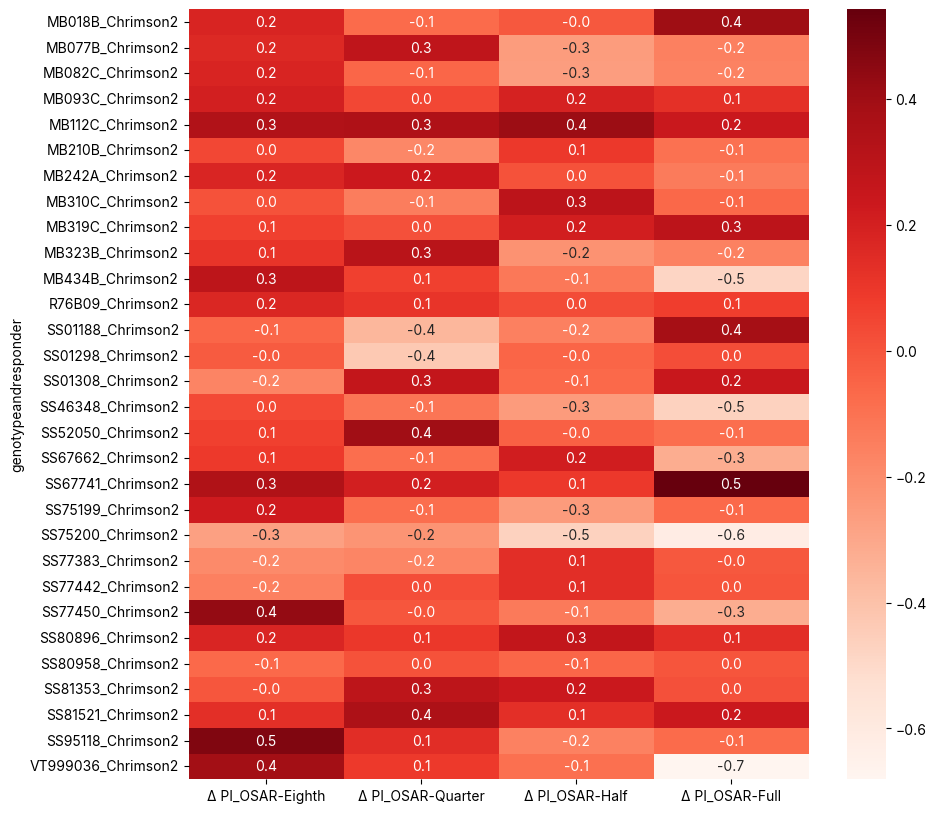

In [8]:
responder = "Chrimson2"

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_lightint = lightintensitycheck[lightintensitycheck['Responder']=="Chrimson2"]
    colormap = "Reds"


if responder == 'ACR':
    responderrename = "GtACR1"
    df_lightint = lightintensitycheck[lightintensitycheck['Responder']=="ACR"]
    colormap = "Greens"


totalpiheatmap = df_lightint.drop(columns=['Responder', 'MBON']).set_index('genotypeandresponder')
fig_heatmappi, ax_heatmappi = plt.subplots(figsize=(10,10))   
 
sns.heatmap(totalpiheatmap, ax=ax_heatmappi, annot=True, fmt=".1f", cmap = colormap)

## Valence signs reversal

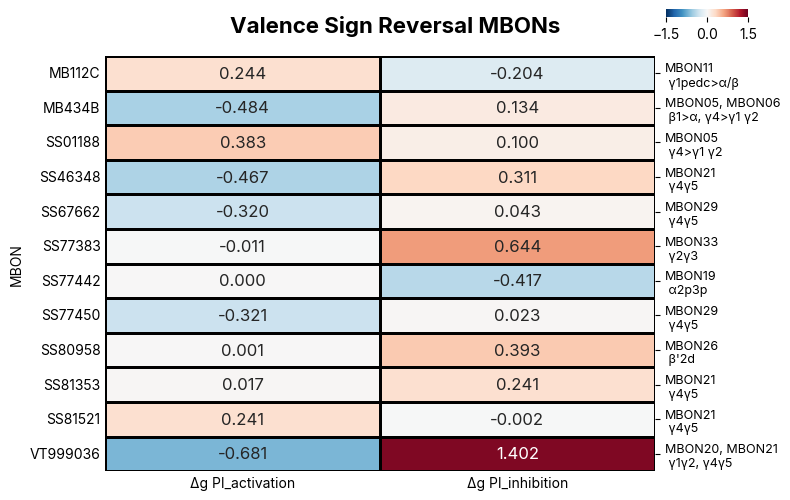

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import NLProcessing
import numpy as np


# Read the Excel files
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Totalcomparisonofallmetrics-Full.xlsx")
osar_chrimson = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
osar_acr = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)

# Extract PI values from both files
activation_pi = osar_chrimson[['MBON', 'PI_Δg_OSAR']].copy()
activation_pi['MBON'] = activation_pi['MBON'].astype(str)
activation_pi = activation_pi.rename(columns={'PI_Δg_OSAR': 'Δg PI_activation'})

inhibition_pi = osar_acr[['MBON', 'PI_Δg_OSAR']].copy()
inhibition_pi['MBON'] = inhibition_pi['MBON'].astype(str)
inhibition_pi = inhibition_pi.rename(columns={'PI_Δg_OSAR': 'Δg PI_inhibition'})

# Create DataFrame for heatmap
heatmapallmbons = activation_pi.merge(inhibition_pi, how="inner", on= "MBON")
mbons_of_interest = ['MB077B', "SS77442", "MB310C"]
heatmap_data = heatmapallmbons[heatmapallmbons['MBON'].isin(mbons_of_interest)].set_index("MBON")


#creating tags for mbon loctions and names
lobloclst = []
mbonloclst = []
df_singleresponder_lobeloc = heatmapallmbons[heatmapallmbons['MBON'].isin(mbons_of_interest)].copy()

for n in df_singleresponder_lobeloc['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_singleresponder_lobeloc['Lobe'] = lobloclst
df_singleresponder_lobeloc['Name'] = mbonloclst

newdf_singleresponder_lobeloc = pd.DataFrame()
naming = df_singleresponder_lobeloc['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df_singleresponder_lobeloc['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf_singleresponder_lobeloc['Merge'] = newlabel

# Create figure and axis
fig_valence, ax_valence = plt.subplots(figsize=(8, 5))

#colorbar for subplot 2
cax2 = inset_axes(ax_valence,
                 width="15%",  # width: 40% of parent_bbox width
                 height="2%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.12, 1.16, 1, 1),
                 bbox_transform=ax_valence.transAxes,
                 borderpad=-2,
                 )
# Create heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdBu_r', center=0, cbar_ax=cax2, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5,0,1.5]),
            linewidths=2, linecolor='black', ax=ax_valence,
            vmin=-1.5, vmax=1.5,
            annot_kws={'size': 12})

ax_valence.set_xticklabels(ax_valence.get_xticklabels(), fontsize = 10)
ax_valence.tick_params(axis='both', which='both', length=0)

#secondary axes for subplot 2 - MBON lobe and naming labels on right side
j8_right = ax_valence.twinx()
j8_right.set_ylim([0,ax_valence.get_ylim()[0]])
j8_right.set_yticks(ax_valence.get_yticks())

#y labels for mbon lobes and naming on subplot 2 (right side)
labellinglist = newdf_singleresponder_lobeloc['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(n)
j8_right.set_yticklabels(labelledlist, fontsize=9)
j8_right.spines['top'].set_visible(False)
j8_right.spines['right'].set_visible(False)
j8_right.spines['bottom'].set_visible(False)
j8_right.spines['left'].set_visible(False)

# Customize plot
fig_valence.suptitle('Valence Sign Reversal MBONs', fontsize=16, fontweight='bold')

# Tight layout
fig_valence.tight_layout()

# Save figure
# plt.savefig(filesavedir + date + "_valencesigreveralmbons.png", dpi = 1200, bbox_inches='tight')

# Show plot



